# Notebook 03: Proposed Consistency-Based Training

The proposed method trains the model to keep predictions stable between clean inputs and lightly corrupted inputs. The objective is:

`L = CE(x) + CE(x') + lambda * KL(p(x) || p(x'))`

The KL coefficient is warmed up during early epochs so the network first learns class-discriminative features before the consistency term becomes strong.

In [9]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
import torch
import matplotlib.pyplot as plt

from robust_cifar.data import make_cifar10_loaders, CIFAR10_CLASSES
from robust_cifar.models import build_resnet18_cifar, count_parameters
from robust_cifar.train import get_device, seed_everything

seed_everything(42)
device = get_device()
device

device(type='cuda')

## Consistency Loader

Each training item returns `(clean_image, corrupted_image, label)` using controlled random corruptions: Gaussian noise, blur, JPEG compression, brightness, and contrast.

In [10]:
train_loader, test_loader = make_cifar10_loaders(
    data_dir=PROJECT_ROOT / "data",
    batch_size=32,
    num_workers=1,
    mode="consistency",
    corruption_severity=2,
    download=True,
)
clean, corrupted, labels = next(iter(train_loader))
clean.shape, corrupted.shape, labels.shape

Files already downloaded and verified
Files already downloaded and verified


(torch.Size([32, 3, 32, 32]), torch.Size([32, 3, 32, 32]), torch.Size([32]))

## Visual Check of Clean and Corrupted Views

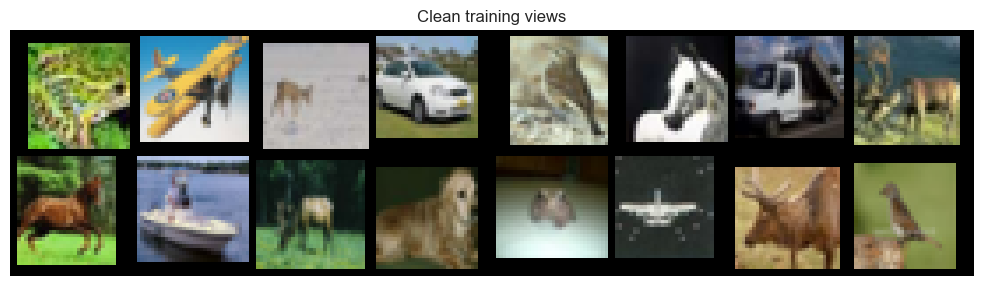

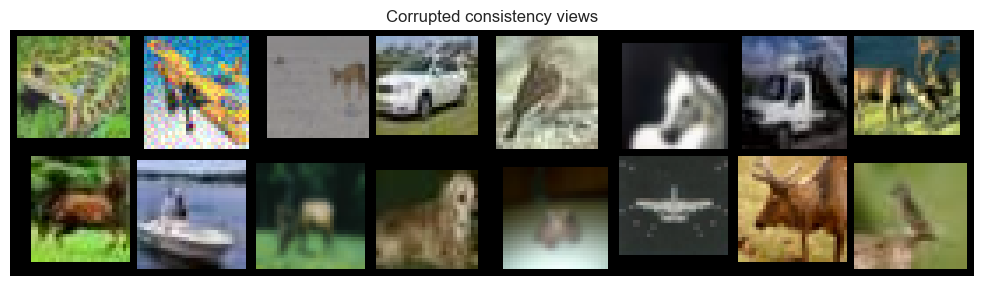

In [11]:
from robust_cifar.visualize import show_batch

show_batch(clean[:16], labels[:16], title="Clean training views")
plt.show()
show_batch(corrupted[:16], labels[:16], title="Corrupted consistency views")
plt.show()

## Train Proposed Model

In [12]:
from robust_cifar.train import train_consistency

model = build_resnet18_cifar()
EPOCHS = 100
history = train_consistency(
    model,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    lr=0.01,
    lambda_kl=0.5,
    warmup_epochs=10,
    device=device,
    output_dir=PROJECT_ROOT / "checkpoints",
    run_name="resnet18_consistency",
)
metrics_df = (
    pd.DataFrame(history)[["epoch", "train_loss", "train_accuracy", "val_loss", "val_accuracy"]]
    .rename(columns={"val_loss": "test_loss", "val_accuracy": "test_accuracy"})
)

for row in metrics_df.itertuples(index=False):
    print(
        f"Epoch {int(row.epoch):03d} | "
        f"Train Loss: {row.train_loss:.4f} | Train Acc: {row.train_accuracy:.4f} | "
        f"Test Loss: {row.test_loss:.4f} | Test Acc: {row.test_accuracy:.4f}"
    )

metrics_df

resnet18_consistency epoch 1/100:   0%|          | 0/1563 [00:03<?, ?it/s]

resnet18_consistency epoch 2/100:   0%|          | 0/1563 [00:04<?, ?it/s]

resnet18_consistency epoch 3/100:   0%|          | 0/1563 [00:04<?, ?it/s]

resnet18_consistency epoch 4/100:   0%|          | 0/1563 [00:04<?, ?it/s]

resnet18_consistency epoch 5/100:   0%|          | 0/1563 [00:04<?, ?it/s]

...

resnet18_consistency epoch 98/100:   0%|          | 0/1563 [00:04<?, ?it/s]

resnet18_consistency epoch 99/100:   0%|          | 0/1563 [00:04<?, ?it/s]

resnet18_consistency epoch 100/100:   0%|          | 0/1563 [00:03<?, ?it/s]

Epoch 001 | Train Loss: 3.1254 | Train Acc: 0.4424 | Test Loss: 1.0987 | Test Acc: 0.6014
Epoch 002 | Train Loss: 2.0039 | Train Acc: 0.6637 | Test Loss: 0.8537 | Test Acc: 0.7024
Epoch 003 | Train Loss: 1.5570 | Train Acc: 0.7499 | Test Loss: 0.6328 | Test Acc: 0.7788
Epoch 004 | Train Loss: 1.3315 | Train Acc: 0.7944 | Test Loss: 0.5394 | Test Acc: 0.8137
Epoch 005 | Train Loss: 1.1870 | Train Acc: 0.8206 | Test Loss: 0.4845 | Test Acc: 0.8328
Epoch 006 | Train Loss: 1.0903 | Train Acc: 0.8392 | Test Loss: 0.4692 | Test Acc: 0.8388
Epoch 007 | Train Loss: 1.0052 | Train Acc: 0.8558 | Test Loss: 0.4664 | Test Acc: 0.8402
Epoch 008 | Train Loss: 0.9488 | Train Acc: 0.8679 | Test Loss: 0.4361 | Test Acc: 0.8529
Epoch 009 | Train Loss: 0.9018 | Train Acc: 0.8746 | Test Loss: 0.3821 | Test Acc: 0.8663
Epoch 010 | Train Loss: 0.8587 | Train Acc: 0.8861 | Test Loss: 0.3644 | Test Acc: 0.8762
Epoch 011 | Train Loss: 0.8172 | Train Acc: 0.8924 | Test Loss: 0.3427 | Test Acc: 0.8824
Epoch 012 

,epoch,train_loss,train_accuracy,test_loss,test_accuracy
0,1,3.125350,0.44238,1.098702,0.6014
1,2,2.003934,0.66370,0.853722,0.7024
2,3,1.557028,0.74988,0.632795,0.7788
3,4,1.331454,0.79442,0.539357,0.8137
4,5,1.187048,0.82062,0.484508,0.8328
...,...,...,...,...,...
95,96,0.016350,0.99990,0.246802,0.9373
96,97,0.015572,0.99998,0.247067,0.9375
97,98,0.015573,0.99992,0.242785,0.9370
98,99,0.016047,0.99992,0.244114,0.9383


## Training and Testing Accuracy Comparison

The table above reports epoch, loss, and accuracy for both training and testing data. The first graph compares training accuracy against testing accuracy; the second graph shows the KL consistency warm-up trend.

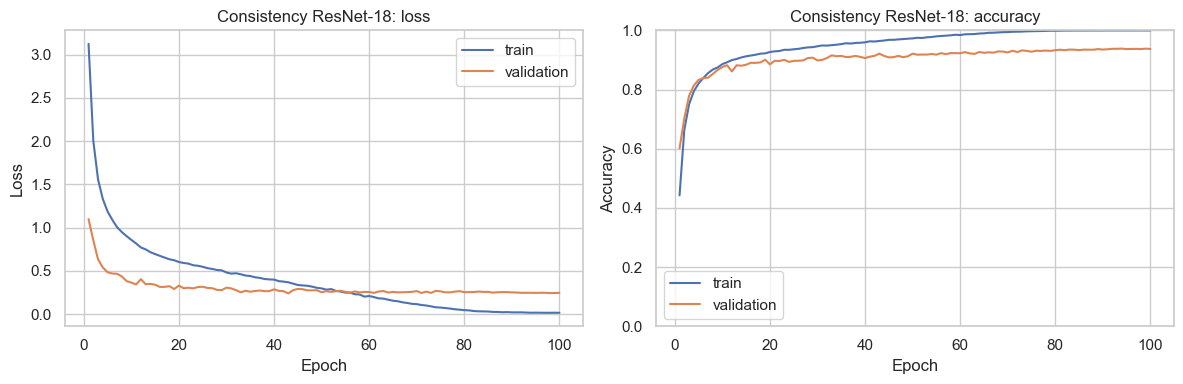

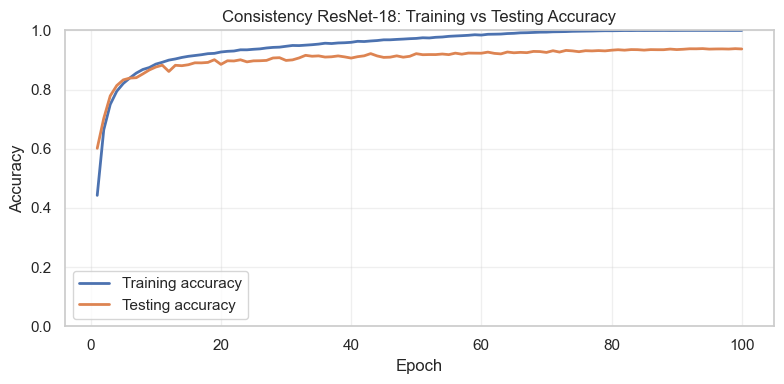

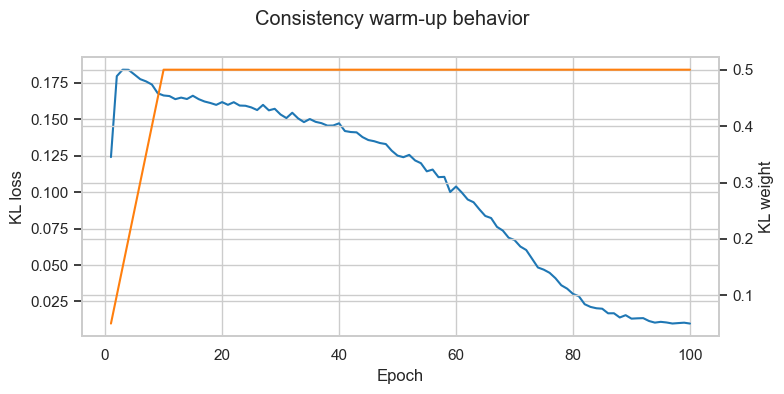

In [13]:
from robust_cifar.visualize import plot_training_history

history_df = pd.DataFrame(history)
plot_training_history(
    history_df,
    title="Consistency ResNet-18",
    output_path=PROJECT_ROOT / "reports" / "figures" / "consistency_training.png",
)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(metrics_df["epoch"], metrics_df["train_accuracy"], label="Training accuracy", linewidth=2)
ax.plot(metrics_df["epoch"], metrics_df["test_accuracy"], label="Testing accuracy", linewidth=2)
ax.set_title("Consistency ResNet-18: Training vs Testing Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports" / "figures" / "consistency_train_test_accuracy.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(history_df["epoch"], history_df["kl"], label="KL loss", color="tab:blue")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("KL loss")
ax2 = ax1.twinx()
ax2.plot(history_df["epoch"], history_df["lambda_kl"], label="lambda", color="tab:orange")
ax2.set_ylabel("KL weight")
fig.suptitle("Consistency warm-up behavior")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports" / "figures" / "consistency_warmup.png", dpi=180, bbox_inches="tight")
plt.show()